The preliminaries

In [1]:
from openai import OpenAI
from scipy.stats import spearmanr
import jsonschema, json
import os
from dotenv import load_dotenv

length_id_batch = 25

#Hidden OpenAI API Key 
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("API Key not found! Ensure you have a .env file with OPENAI_API_KEY defined.")

client = OpenAI(api_key=api_key)

#Pull in AIME and GPQA Diamond
with open('aime_pool.json', 'r') as f:
    aime_data = json.load(f)

# Load the GPQA pool
with open('gpqa_pool.json', 'r') as f:
    gpqa_data = json.load(f)

# Load my assignment
with open('asudit.json', 'r') as f:
    asudit_data = json.load(f)

# Verify the data loaded correctly
print(f"Loaded {len(aime_data)} items from AIME")
print(f"Loaded {len(gpqa_data)} items from GPQA")
print(f"Loaded {len(asudit_data)} items from asudit")

#split case_ids
gpqa_id = asudit_data["case_ids"][:length_id_batch]
aime_id = asudit_data["case_ids"][length_id_batch:]

gpqa_data_filter = {}
gpqa_responses = {}

for case in gpqa_data:
    if case['case_id'] in gpqa_id:
        gpqa_data_filter[case['case_id']] = case
        gpqa_responses[case['case_id']] = {}

aime_data_filter = {}
aime_responses = {}
for case in aime_data:
    if case['case_id'] in aime_id:
        aime_data_filter[case['case_id']] = case
        aime_responses[case['case_id']] = {}

#print(gpqa_id)
#print(aime_id)
print(len(gpqa_data_filter), len(aime_data_filter))

Loaded 196 items from AIME
Loaded 198 items from GPQA
Loaded 4 items from asudit
25 25


1. Builds a prompt and queries the model K = 50 times with temperature=1.0 passed explicitly on every call (do not omit the parameter and rely on the API default). The exact model(s) you call are determined by your axis assignment (see the table in Your Assignment below).

In [ ]:
#Axis C mid-vs-frontier: gpt-4.1-mini (zero-shot) [Condition A] vs gpt-4.1 (zero-shot) [Condition B]
import copy
from concurrent.futures import ThreadPoolExecutor
from pydantic import BaseModel, Field
from typing import Literal

#models = ["gpt-4.1-mini", "gpt-4.1"]
#benchmarks = ['gpqa_diamond', 'aime']
#ground_truth = ['correct_letter', 'correct_answer']

# I use pydantic here to prevent the model from reverting to CoT reasoning in the answer,
# instead forcing a zero-shot to the correct answer
# Schema for GPQA (Multiple Choice)
#lass GPQAResponse(BaseModel):
#    answer: Literal["A", "B", "C", "D"]

# Schema for AIME (Integer)
#class AIMEResponse(BaseModel):
#    answer: int = Field(ge=0, le=999) # Ensures the integer is between 0 and 999

def generate_gpqa_prompt(subject):
    """
    Zero-shot GPQA prompt with a parseable final-answer marker.
    The prompt asks for a brief solution summary, not step-by-step CoT.
    """
    return f"""You are answering a graduate-level multiple-choice question in {subject}.

Rules:
- Single-agent only.
- Do not use tools, web search, external retrieval, or multi-turn interaction.
- Choose exactly one answer choice: A, B, C, or D.
- Provide a brief solution summary, not a detailed step-by-step derivation.
- The final line must have exactly this form:

FINAL_ANSWER: <A, B, C, or D>

Required output format:
SOLUTION_SUMMARY:
<2-5 concise sentences explaining the basis for your answer>

FINAL_ANSWER: <one capital letter: A, B, C, or D>

Do not put anything after the FINAL_ANSWER line."""

system_prompt_aime = """You are solving a math problem from the American Invitational Mathematics Examination.

Rules:
- Single-agent only.
- Do not use tools, web search, external retrieval, or multi-turn interaction.
- The answer must be an integer from 0 to 999.
- Provide a brief solution summary, not a detailed step-by-step derivation.
- The final line must have exactly this form:

FINAL_ANSWER: <integer from 0 to 999>

Required output format:
SOLUTION_SUMMARY:
<2-5 concise sentences explaining the basis for your answer>

FINAL_ANSWER: <one integer from 0 to 999>

Do not put anything after the FINAL_ANSWER line."""

import re

FINAL_ANSWER_RE = re.compile(
    r"(?im)^[ \t]*FINAL_ANSWER[ \t]*:[ \t]*(?P<answer>[^\r\n]*)[ \t]*$"
)

def extract_final_answer_line(raw_text):
    """
    Extracts the answer text from the last FINAL_ANSWER line.
    Returns None if no such line exists.
    """
    if not isinstance(raw_text, str):
        return None

    matches = list(FINAL_ANSWER_RE.finditer(raw_text))

    if not matches:
        return None

    return matches[-1].group("answer").strip()

def parse_gpqa_response(raw_text):
    """
    Parse GPQA response into "A", "B", "C", "D", or "_UNPARSEABLE_".
    """
    candidate = extract_final_answer_line(raw_text)

    if candidate is None:
        candidate = raw_text.strip()

    candidate = candidate.strip().upper()

    match = re.fullmatch(r"([ABCD])\.?", candidate)

    if match:
        return match.group(1)

    return "_UNPARSEABLE_"


def parse_aime_response(raw_text):
    """
    Parse AIME response into an int from 0 to 999, or "_UNPARSEABLE_".
    """
    candidate = extract_final_answer_line(raw_text)

    if candidate is None:
        candidate = raw_text.strip()

    candidate = candidate.strip()

    match = re.fullmatch(r"(\d{1,3})\.?", candidate)

    if not match:
        return "_UNPARSEABLE_"

    value = int(match.group(1))

    if 0 <= value <= 999:
        return value

    return "_UNPARSEABLE_"


def parse_response(raw_text, benchmark):
    if benchmark == "gpqa":
        return parse_gpqa_response(raw_text)
    elif benchmark == "aime":
        return parse_aime_response(raw_text)
    else:
        raise ValueError(f"Unknown benchmark: {benchmark}")

import time
import random
#from concurrent.futures import ThreadPoolExecutor

def run_agent(system_prompt,
              model,
              user_message,
              case_id,
              repository,
              benchmark,
              iterations=50,
              max_workers=10,
              max_retries=4):
    '''
    Runs K independent samples for one case.

    Stores:
      - answers: parsed answers used for metrics
      - raw_responses: full raw model text, preserving rationale
      - sample_records: metadata useful for debugging
    '''
    
    messages = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message},]
    
    repository[case_id]["answers"] = []
    repository[case_id]["raw_responses"] = []
    repository[case_id]["sample_records"] = []
    
   
    
    def get_completion(sample_index):
        for attempt in range(max_retries + 1):
            try:
                resp = client.chat.completions.create(
                    model=model, 
                    messages=messages, 
                    max_tokens=700, 
                    temperature=1.0
                )
                
                choice = resp.choices[0]
                raw_text = choice.message.content
                parsed_answer = parse_response(raw_text, benchmark)
                
                return {
                    "sample_index": sample_index,
                    "raw_response": raw_text,
                    "parsed_answer": parsed_answer,
                    "finish_reason": choice.finish_reason,
                    "api_error": None,
                }
            
            except Exception as e:
                
                if attempt < max_retries:
                    sleep_time = (2 ** attempt) + random.random()
                    time.sleep(sleep_time)
                else:
                    # recommend failing instead of silently counting API failures
                    # as "_UNPARSEABLE_".
                    raise RuntimeError(
                        f"API failed for case_id={case_id}, "
                        f"model={model}, sample_index={sample_index}"
                    ) from e
    
    # Use ThreadPoolExecutor to run iterations in parallel
    # max_workers=20 is a safe starting point to avoid hitting rate limits too fast
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        sample_records = list(executor.map(get_completion, range(iterations)))

    repository[case_id]["sample_records"] = sample_records
    repository[case_id]["raw_responses"] = [
            r["raw_response"] for r in sample_records
    ]
    repository[case_id]["answers"] = [
        r["parsed_answer"] for r in sample_records
    ]

    print(
        f"Completed {iterations} iterations for case {case_id} "
        f"using {model}; "
        f"unparseable={repository[case_id]['answers'].count('_UNPARSEABLE_')}"
    )
    
   
        
       
gpqa_repo = {"gpt-4.1-mini":copy.deepcopy(gpqa_responses), "gpt-4.1":copy.deepcopy(gpqa_responses)}
models = ["gpt-4.1-mini", "gpt-4.1"]

def format_gpqa_user_message(case):
    """
    Build the full GPQA user message.

    If choices are stored separately in case["options"], include them.
    If the question already contains labeled choices, return it as-is.
    """
    question = case["question"].strip()

    options = case.get("options")

    if isinstance(options, dict):
        option_lines = []

        for letter in ["A", "B", "C", "D"]:
            if letter not in options:
                raise ValueError(
                    f"Missing option {letter} for case_id={case.get('case_id')}"
                )

            option_lines.append(f"{letter}. {options[letter]}")

        option_text = "\n".join(option_lines)

        return f"""Question:
{question}

Answer choices:
{option_text}"""

    

for model in gpqa_repo.keys():
    for case_id in gpqa_id:
        case = gpqa_data_filter[case_id]
        system_prompt_gpqa = generate_gpqa_prompt(case['subject'])
        
        run_agent(system_prompt=system_prompt_gpqa,
                  model=model,
                  user_message=format_gpqa_user_message(case),
                  case_id=case_id,
                  repository=gpqa_repo[model],
                  benchmark="gpqa",
                  iterations=50,
                  max_workers=10)

    # Save after all 25 GPQA cases for this model are done
    with open(f"raw_gpqa_{model}_results.json", "w") as f:
        json.dump(gpqa_repo[model], f, indent=4)

aime_repo = {"gpt-4.1-mini":copy.deepcopy(aime_responses), "gpt-4.1":copy.deepcopy(aime_responses)}
for model in aime_repo.keys():
    for case_id in aime_id:
        case = aime_data_filter[case_id]
        #system_prompt_gpqa = generate_gpqa_prompt(gpqa_data_filter[id]['subject'])
        run_agent(system_prompt=system_prompt_aime,
                  model=model,
                  user_message=case['question'],
                  case_id=case_id,
                  repository=aime_repo[model],
                  benchmark="aime",
                  iterations=50,
                  max_workers=10)
    
    # Save after all 25 AIME cases for this model are done
    with open(f"raw_aime_{model}_results.json", "w") as f:
        json.dump(aime_repo[model], f, indent=4)





Completed 50 iterations for case aime_160 using gpt-4.1-mini; unparseable=18
Completed 50 iterations for case aime_076 using gpt-4.1-mini; unparseable=0
Completed 50 iterations for case aime_161 using gpt-4.1-mini; unparseable=4
Completed 50 iterations for case aime_019 using gpt-4.1-mini; unparseable=9
Completed 50 iterations for case aime_192 using gpt-4.1-mini; unparseable=44
Completed 50 iterations for case aime_005 using gpt-4.1-mini; unparseable=11
Completed 50 iterations for case aime_167 using gpt-4.1-mini; unparseable=21
Completed 50 iterations for case aime_112 using gpt-4.1-mini; unparseable=6
Completed 50 iterations for case aime_096 using gpt-4.1-mini; unparseable=0
Completed 50 iterations for case aime_012 using gpt-4.1-mini; unparseable=5
Completed 50 iterations for case aime_087 using gpt-4.1-mini; unparseable=9
Completed 50 iterations for case aime_032 using gpt-4.1-mini; unparseable=49
Completed 50 iterations for case aime_009 using gpt-4.1-mini; unparseable=0
Complet

2. We already parsed the output while calling the OpenAI API in task 1, so the focus of this code block is QA/QC of the data. 

In [16]:
import pandas as pd

dataset_names = ["gpqa", "aime"]
models = ["gpt-4.1-mini", "gpt-4.1"]
master_rows = []
condition_for_model = {
    "gpt-4.1-mini": "a",
    "gpt-4.1": "b",
}

for model in models:
    for dataset in dataset_names:
        with open(f'raw_{dataset}_{model}_results.json', 'r') as f:
            data = json.load(f)

        for case_id, info in data.items():
            # Add metadata so I can group/filter later
            row = dict(info)
            row["case_id"] = case_id
            row["model_name"] = model   
            row["benchmark"] = dataset
            row["condition"] = condition_for_model[model]
            master_rows.append(row)
            

# Create one single DF for all 100 entries
full_df = pd.DataFrame(master_rows)

print(f"Total rows: {len(full_df)}")

if len(full_df) != 100:
    print(f"ERROR: Expected 100 rows, found {len(full_df)}")

required_columns = {
    "case_id",
    "model_name",
    "benchmark",
    "condition",
    "answers",
}

missing_columns = required_columns - set(full_df.columns)

if missing_columns:
    print(f"ERROR: Missing required columns: {missing_columns}")
else:
    print("All required columns are present.")

#Run Quality Control Checks for Parsing Task
# (a) Check length of answers list in every row
full_df['sample_count'] = full_df['answers'].apply(len)

# Flag specific case_ids that failed to reach K=50
if (full_df['sample_count'] != 50).any():
    print("\nERROR: Missing samples detected in these cases:")
    print(full_df[full_df['sample_count'] != 50][['case_id', 'model_name', 'sample_count']])
else:
    print("\nAll rows have exactly K=50 samples.")

if "raw_responses" in full_df.columns:
    full_df["raw_response_count"] = full_df["raw_responses"].apply(len)

    if (full_df["raw_response_count"] != 50).any():
        print("\nERROR: Missing raw responses detected in these cases:")
        print(
            full_df[
                full_df["raw_response_count"] != 50
            ][["case_id", "model_name", "benchmark", "raw_response_count"]]
        )
    else:
        print("\nAll rows have exactly K=50 raw responses.")

if "sample_records" in full_df.columns:
    full_df["sample_record_count"] = full_df["sample_records"].apply(len)

    if (full_df["sample_record_count"] != 50).any():
        print("\nERROR: Missing sample records detected in these cases:")
        print(
            full_df[
                full_df["sample_record_count"] != 50
            ][["case_id", "model_name", "benchmark", "sample_record_count"]]
        )
    else:
        print("\nAll rows have exactly K=50 sample records.")

# (b) Verify experimental balance
print("\n--- Experimental Balance Check ---")

# Check Model distribution: Should be 50 'gpt-4.1-mini' and 50 'gpt-4.1'
print("Counts by Model Name:")
print(full_df['model_name'].value_counts())

# Check Condition distribution: Should be 50 'a' and 50 'b'
print("\nCounts by Condition Label:")
print(full_df['condition'].value_counts())

# Check Benchmark distribution: Should be 50 'gpqa' and 50 'aime'
print("\nCounts by Benchmark Dataset:")
print(full_df['benchmark'].value_counts())

# Cross-tabulation: Each cell in this 2x2 matrix must be exactly 25
print("\nSegment Balance (Expected: 25 per cell):")
segment_check = pd.crosstab(full_df['model_name'], full_df['benchmark'])
print(segment_check)

expected_segment_counts = pd.DataFrame(
    25,
    index=models,
    columns=dataset_names,
)

segment_check = segment_check.reindex(index=models, columns=dataset_names)

print("\nSegment Balance Expected:")
print(expected_segment_counts)

print("\nSegment Balance Observed:")
print(segment_check)

if not segment_check.equals(expected_segment_counts):
    print("\nERROR: Segment balance is not 25 per model/benchmark cell.")
else:
    print("\nSegment balance is correct.")

#Verify the Output of the Answers

# --- GPQA SECTION ---
valid_gpqa_set = {'A', 'B', 'C', 'D', '_UNPARSEABLE_'}

def find_invalid_gpqa(answers):
    return [a for a in answers if a not in valid_gpqa_set]

# 1. Isolate
gpqa_only = full_df[full_df['benchmark'] == 'gpqa'].copy()

# 2. Apply function DIRECTLY to the slice
gpqa_only['invalid_gpqa'] = gpqa_only['answers'].apply(find_invalid_gpqa)

# 3. Check length (Safe because there are no AIME NaNs in gpqa_only)
gpqa_errors = gpqa_only[gpqa_only['invalid_gpqa'].map(len) > 0]
print(f"GPQA Rows with invalid sample values: {len(gpqa_errors)}")


# --- AIME SECTION ---
def find_invalid_aime(answers):
    invalid_found = []
    for a in answers:
        if a == '_UNPARSEABLE_':
            continue
        if not isinstance(a, int) or not (0 <= a <= 999):
            invalid_found.append(a)
    return invalid_found

# 1. Isolate
aime_only = full_df[full_df['benchmark'] == 'aime'].copy()

# 2. Apply function DIRECTLY to the slice
aime_only['invalid_aime'] = aime_only['answers'].apply(find_invalid_aime)

# 3. Check length (Safe because there are no GPQA NaNs in aime_only)
aime_errors = aime_only[aime_only['invalid_aime'].map(len) > 0]
print(f"AIME Rows with invalid sample values: {len(aime_errors)}")

def count_unparseable(answers):
    return sum(a == "_UNPARSEABLE_" for a in answers)

full_df["unparseable_count"] = full_df["answers"].apply(count_unparseable)
full_df["unparseable_rate"] = full_df["unparseable_count"] / full_df["sample_count"]

print("\nUnparseable Summary:")
print(
    full_df.groupby(["benchmark", "model_name"])["unparseable_count"]
    .agg(["sum", "mean", "max"])
)

Total rows: 100
All required columns are present.

All rows have exactly K=50 samples.

All rows have exactly K=50 raw responses.

All rows have exactly K=50 sample records.

--- Experimental Balance Check ---
Counts by Model Name:
model_name
gpt-4.1-mini    50
gpt-4.1         50
Name: count, dtype: int64

Counts by Condition Label:
condition
a    50
b    50
Name: count, dtype: int64

Counts by Benchmark Dataset:
benchmark
gpqa    50
aime    50
Name: count, dtype: int64

Segment Balance (Expected: 25 per cell):
benchmark     aime  gpqa
model_name              
gpt-4.1         25    25
gpt-4.1-mini    25    25

Segment Balance Expected:
              gpqa  aime
gpt-4.1-mini    25    25
gpt-4.1         25    25

Segment Balance Observed:
benchmark     gpqa  aime
model_name              
gpt-4.1-mini    25    25
gpt-4.1         25    25

Segment balance is correct.
GPQA Rows with invalid sample values: 0
AIME Rows with invalid sample values: 0

Unparseable Summary:
                       

3. Computes per-case metrics — consistency C, accuracy A, risk-adjusted accuracy 𝑅𝛼, and the Wilson lower bound R_wilson (formulas in The Data → Metrics below).

In [17]:
#Create DataFrames of "Ground Truth"
master_rows = []

for dataset in dataset_names:
    with open(f'{dataset}_pool.json', 'r') as f:
        data = json.load(f)

    for case in data:
            # Add metadata so I can group/filter later
        row = dict(case)
        #row["case_id"] = case_id
           
        row["benchmark"] = dataset
        if dataset == "aime":
            row["ground_truth"] = row.pop("correct_answer")
        else:
            row["ground_truth"] = row.pop("correct_letter")
        master_rows.append(row)
            
truth_df = pd.DataFrame(master_rows)[["benchmark", "case_id", "ground_truth"]]

merged_df = pd.merge(
    left=full_df,
    right=truth_df,
    on=["benchmark", "case_id"],
    how="left",
    validate="many_to_one"
)

if merged_df["ground_truth"].isna().any():
    print("ERROR: Some rows are missing ground truth.")
    print(merged_df[merged_df["ground_truth"].isna()][["benchmark", "case_id", "model_name"]])
else:
    print("All rows have ground truth.")

from scipy import stats

from collections import Counter
import numpy as np

K_EXPECTED = 50

def get_majority_answer_and_count(answers, benchmark):
    """
    Returns the majority answer and majority count.

    GPQA:
      - Answers are strings.
      - Tie-break by lexicographically smallest tied answer.

    AIME:
      - Integer answers tie-break by smallest integer.
      - If _UNPARSEABLE_ is strictly most common, it can be majority.
      - If _UNPARSEABLE_ ties with integer answers, prefer the smallest integer.
    """
    counts = Counter(answers)
    max_count = max(counts.values())
    tied = [answer for answer, count in counts.items() if count == max_count]

    if benchmark == "gpqa":
        majority_answer = min(tied)
    elif benchmark == "aime":
        tied_ints = [answer for answer in tied if isinstance(answer, int)]

        if tied_ints:
            majority_answer = min(tied_ints)
        else:
            majority_answer = "_UNPARSEABLE_"
    else:
        raise ValueError(f"Unknown benchmark: {benchmark}")

    return majority_answer, max_count


def count_correct_answers(answers, ground_truth):
    return sum(answer == ground_truth for answer in answers)


def make_answer_counts(answers, benchmark):
    """
    Creates answer_counts in a JSON-friendly way.

    For GPQA, include all possible answer keys.
    For AIME, stringify integer keys because JSON object keys must be strings.
    """
    counts = Counter(answers)

    if benchmark == "gpqa":
        return {
            "A": int(counts.get("A", 0)),
            "B": int(counts.get("B", 0)),
            "C": int(counts.get("C", 0)),
            "D": int(counts.get("D", 0)),
            "_UNPARSEABLE_": int(counts.get("_UNPARSEABLE_", 0)),
        }

    if benchmark == "aime":
        integer_answers = sorted(
            answer for answer in counts
            if isinstance(answer, int)
        )

        answer_counts = {
            str(answer): int(counts[answer])
            for answer in integer_answers
        }

        if counts.get("_UNPARSEABLE_", 0) > 0:
            answer_counts["_UNPARSEABLE_"] = int(counts["_UNPARSEABLE_"])

        return answer_counts

    raise ValueError(f"Unknown benchmark: {benchmark}")

# Number of samples
merged_df["K"] = merged_df["answers"].apply(len)

if (merged_df["K"] != K_EXPECTED).any():
    print("ERROR: Some rows do not have K=50 samples.")
    print(merged_df[merged_df["K"] != K_EXPECTED][["benchmark", "case_id", "model_name", "K"]])
else:
    print("All rows have K=50 samples.")

# Majority answer and consistency
majority_info = merged_df.apply(
    lambda row: get_majority_answer_and_count(row["answers"], row["benchmark"]),
    axis=1
)

merged_df[["majority_answer", "n_majority"]] = pd.DataFrame(
    majority_info.tolist(),
    index=merged_df.index
)

merged_df["C"] = merged_df["n_majority"] / merged_df["K"]

# Accuracy
merged_df["n_correct"] = merged_df.apply(
    lambda row: count_correct_answers(row["answers"], row["ground_truth"]),
    axis=1
)

merged_df["A"] = merged_df["n_correct"] / merged_df["K"]

# Answer counts
merged_df["answer_counts"] = merged_df.apply(
    lambda row: make_answer_counts(row["answers"], row["benchmark"]),
    axis=1
)

for alpha in [0, 1, 2]:
    penalty = alpha * np.sqrt(merged_df["A"] * (1 - merged_df["A"]))
    merged_df[f"R_{alpha}"] = np.maximum(0, merged_df["A"] - penalty)

z = 1.96
n = merged_df["K"]
A = merged_df["A"]

merged_df["R_wilson"] = (
    A
    + z**2 / (2 * n)
    - z * np.sqrt((A * (1 - A) / n) + (z**2 / (4 * n**2)))
) / (
    1 + z**2 / n
)

metric_cols = ["C", "A", "R_0", "R_1", "R_2", "R_wilson"]

merged_df[metric_cols] = merged_df[metric_cols].round(4)

# answer_counts should sum to K
merged_df["answer_count_sum"] = merged_df["answer_counts"].apply(lambda d: sum(d.values()))

bad_answer_counts = merged_df[merged_df["answer_count_sum"] != merged_df["K"]]

if len(bad_answer_counts) > 0:
    print("ERROR: Some answer_counts do not sum to K.")
    print(
        bad_answer_counts[
            ["benchmark", "case_id", "model_name", "K", "answer_count_sum", "answer_counts"]
        ]
    )
else:
    print("All answer_counts sum to K.")

# R_0 should equal A
if not np.allclose(merged_df["R_0"], merged_df["A"]):
    print("ERROR: R_0 does not equal A.")
else:
    print("R_0 equals A.")

# Metrics should be in [0, 1]
for col in metric_cols:
    bad = merged_df[~merged_df[col].between(0, 1)]

    if len(bad) > 0:
        print(f"ERROR: {col} has values outside [0, 1].")
        print(bad[["benchmark", "case_id", "model_name", col]])


#Output to JSON for inspection
merged_df.to_json("Merged_results_pre_final.json", orient="records", indent=4)


All rows have ground truth.
All rows have K=50 samples.
All answer_counts sum to K.
R_0 equals A.


4. Validates and serializes the results into a single {PennKey}_results.json (for example, dkaihua_results.json) that satisfies the provided JSON schema, then computes per-cell Spearman for the report.

In [18]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr

PENN_KEY = "asudit"  

OUTPUT_PATH = Path(f"{PENN_KEY}_results.json")
SPEARMAN_PATH = Path(f"{PENN_KEY}_spearman.csv")

final_df = merged_df.copy()

#Standardize the Benchmark name to match the project assignment
final_df["benchmark"] = final_df["benchmark"].replace({
    "gpqa": "gpqa_diamond",
    "aime": "aime"
})

#Final QC checks, just in case - most of the QA/QC was already done by prior tasks
assert len(final_df) == 100, f"Expected 100 rows, found {len(final_df)}"
assert set(final_df["benchmark"]) == {"gpqa_diamond", "aime"}
assert set(final_df["condition"]) == {"a", "b"}

metric_cols = ["C", "A", "R_0", "R_1", "R_2", "R_wilson"]

for col in metric_cols:
    assert final_df[col].between(0, 1).all(), f"{col} has values outside [0, 1]"



#Create the Final List of Results to feed into JSON
final_df = final_df.sort_values(
    by=["benchmark", "case_id", "condition"]
).reset_index(drop=True)

results = []

for _, row in final_df.iterrows():
    benchmark = row["benchmark"]

    entry = {
        "case_id": str(row["case_id"]),
        "benchmark": benchmark,
        "condition": str(row["condition"]),
        "K": int(row["K"]),
        "answer_counts": row["answer_counts"],
        "majority_answer": row["majority_answer"],
        "ground_truth": row["ground_truth"],
        "C": round(float(row["C"]), 4),
        "A": round(float(row["A"]), 4),
        "R_0": round(float(row["R_0"]), 4),
        "R_1": round(float(row["R_1"]), 4),
        "R_2": round(float(row["R_2"]), 4),
        "R_wilson": round(float(row["R_wilson"]), 4),
    }

    results.append(entry)

#Build Submission and Save to JSON
submission = {
    "meta": {
        "penn_key": "asudit",
        "axis": "C",
        "condition_a_model": "gpt-4.1-mini",
        "condition_b_model": "gpt-4.1",
        "condition_a_prompt": "zero_shot_brief_rationale",
        "condition_b_prompt": "zero_shot_brief_rationale",
        "K": 50,
        "temperature": 1.0,
    },
    "results": results,
}

with OUTPUT_PATH.open("w") as f:
    json.dump(submission, f, indent=2)

print(f"Wrote {OUTPUT_PATH}")







Wrote asudit_results.json


In [19]:
#JSON Schema Validator

# -----------------------------
# Final JSON Validator
# -----------------------------

import json
import math
from pathlib import Path


RESULTS_PATH = Path("asudit_results.json")


def validate_results_json(path):
    errors = []

    with open(path, "r") as f:
        payload = json.load(f)

    # -----------------------------
    # Top-level checks
    # -----------------------------
    if not isinstance(payload, dict):
        errors.append("Top-level JSON must be an object/dict.")
        return errors

    if set(payload.keys()) != {"meta", "results"}:
        errors.append(
            f"Top-level keys must be exactly {{'meta', 'results'}}, found {set(payload.keys())}."
        )

    meta = payload.get("meta")
    results = payload.get("results")

    # -----------------------------
    # Meta checks
    # -----------------------------
    required_meta_keys = {
        "penn_key",
        "axis",
        "condition_a_model",
        "condition_b_model",
        "condition_a_prompt",
        "condition_b_prompt",
        "K",
        "temperature",
    }

    if not isinstance(meta, dict):
        errors.append("meta must be an object/dict.")
    else:
        missing_meta = required_meta_keys - set(meta.keys())
        extra_meta = set(meta.keys()) - required_meta_keys

        if missing_meta:
            errors.append(f"meta is missing keys: {missing_meta}")

        if extra_meta:
            errors.append(f"meta has extra keys: {extra_meta}")

        if meta.get("axis") not in {"A", "B", "C"}:
            errors.append(f"meta.axis must be A, B, or C; found {meta.get('axis')}.")

        if meta.get("K") != 50:
            errors.append(f"meta.K must equal 50; found {meta.get('K')}.")

        if meta.get("temperature") != 1.0:
            errors.append(
                f"meta.temperature must equal 1.0; found {meta.get('temperature')}."
            )

    # -----------------------------
    # Results list checks
    # -----------------------------
    if not isinstance(results, list):
        errors.append("results must be a list.")
        return errors

    if len(results) != 100:
        errors.append(f"results must contain exactly 100 entries; found {len(results)}.")

    required_entry_keys = {
        "case_id",
        "benchmark",
        "condition",
        "K",
        "majority_answer",
        "ground_truth",
        "answer_counts",
        "C",
        "A",
        "R_0",
        "R_1",
        "R_2",
        "R_wilson",
    }

    metric_keys = ["C", "A", "R_0", "R_1", "R_2", "R_wilson"]
    seen_keys = set()

    for i, entry in enumerate(results):
        prefix = f"results[{i}]"

        if not isinstance(entry, dict):
            errors.append(f"{prefix}: entry must be an object/dict.")
            continue

        missing = required_entry_keys - set(entry.keys())
        extra = set(entry.keys()) - required_entry_keys

        if missing:
            errors.append(f"{prefix}: missing keys {missing}")

        if extra:
            errors.append(f"{prefix}: extra keys {extra}")

        # Skip deeper checks if basic fields are missing.
        if missing:
            continue

        case_id = entry["case_id"]
        benchmark = entry["benchmark"]
        condition = entry["condition"]
        K = entry["K"]
        majority_answer = entry["majority_answer"]
        ground_truth = entry["ground_truth"]
        answer_counts = entry["answer_counts"]

        # Unique result key.
        key = (benchmark, case_id, condition)
        if key in seen_keys:
            errors.append(f"{prefix}: duplicate benchmark/case_id/condition key {key}.")
        seen_keys.add(key)

        # Basic type/value checks.
        if not isinstance(case_id, str):
            errors.append(f"{prefix}: case_id must be a string.")

        if benchmark not in {"gpqa_diamond", "aime"}:
            errors.append(
                f"{prefix}: benchmark must be 'gpqa_diamond' or 'aime'; found {benchmark}."
            )

        if condition not in {"a", "b"}:
            errors.append(f"{prefix}: condition must be 'a' or 'b'; found {condition}.")

        if K != 50:
            errors.append(f"{prefix}: K must equal 50; found {K}.")

        if not isinstance(answer_counts, dict):
            errors.append(f"{prefix}: answer_counts must be an object/dict.")
            continue

        # answer_counts values.
        for ans_key, count in answer_counts.items():
            if not isinstance(ans_key, str):
                errors.append(f"{prefix}: answer_counts key {ans_key} is not a string.")

            if not isinstance(count, int):
                errors.append(
                    f"{prefix}: answer_counts[{ans_key!r}] must be an integer count."
                )
            elif count < 0:
                errors.append(
                    f"{prefix}: answer_counts[{ans_key!r}] must be nonnegative."
                )

        count_sum = sum(answer_counts.values())

        if count_sum != K:
            errors.append(
                f"{prefix}: answer_counts sum to {count_sum}, but K is {K}."
            )

        # Metric checks.
        for metric in metric_keys:
            value = entry[metric]

            if not isinstance(value, (int, float)):
                errors.append(f"{prefix}: {metric} must be numeric.")
                continue

            if not math.isfinite(value):
                errors.append(f"{prefix}: {metric} is not finite.")
                continue

            if not (0 <= value <= 1):
                errors.append(f"{prefix}: {metric}={value} is outside [0, 1].")

        if abs(entry["R_0"] - entry["A"]) > 1e-4:
            errors.append(
                f"{prefix}: R_0 must equal A; found R_0={entry['R_0']}, A={entry['A']}."
            )

        # Benchmark-specific answer checks.
        if benchmark == "gpqa_diamond":
            valid_gpqa_answers = {"A", "B", "C", "D", "_UNPARSEABLE_"}

            invalid_keys = set(answer_counts.keys()) - valid_gpqa_answers
            if invalid_keys:
                errors.append(
                    f"{prefix}: invalid GPQA answer_counts keys {invalid_keys}."
                )

            if majority_answer not in valid_gpqa_answers:
                errors.append(
                    f"{prefix}: invalid GPQA majority_answer {majority_answer}."
                )

            if ground_truth not in {"A", "B", "C", "D"}:
                errors.append(f"{prefix}: invalid GPQA ground_truth {ground_truth}.")

            # Accuracy should match answer_counts.
            expected_A = round(answer_counts.get(ground_truth, 0) / K, 4)
            if abs(entry["A"] - expected_A) > 1e-4:
                errors.append(
                    f"{prefix}: A={entry['A']} but answer_counts imply A={expected_A}."
                )

        elif benchmark == "aime":
            # AIME answer_counts keys should be stringified ints or _UNPARSEABLE_.
            for ans_key in answer_counts.keys():
                if ans_key == "_UNPARSEABLE_":
                    continue

                if not ans_key.isdigit():
                    errors.append(
                        f"{prefix}: AIME answer_counts key {ans_key!r} is not a digit string."
                    )
                elif not (0 <= int(ans_key) <= 999):
                    errors.append(
                        f"{prefix}: AIME answer_counts key {ans_key!r} is outside [0, 999]."
                    )

            if majority_answer != "_UNPARSEABLE_":
                if not isinstance(majority_answer, int):
                    errors.append(
                        f"{prefix}: AIME majority_answer must be int or '_UNPARSEABLE_'; "
                        f"found {majority_answer!r}."
                    )
                elif not (0 <= majority_answer <= 999):
                    errors.append(
                        f"{prefix}: AIME majority_answer {majority_answer} outside [0, 999]."
                    )

            if not isinstance(ground_truth, int):
                errors.append(
                    f"{prefix}: AIME ground_truth must be an int; found {ground_truth!r}."
                )
            elif not (0 <= ground_truth <= 999):
                errors.append(
                    f"{prefix}: AIME ground_truth {ground_truth} outside [0, 999]."
                )

            # Accuracy should match answer_counts.
            if isinstance(ground_truth, int):
                expected_A = round(answer_counts.get(str(ground_truth), 0) / K, 4)
                if abs(entry["A"] - expected_A) > 1e-4:
                    errors.append(
                        f"{prefix}: A={entry['A']} but answer_counts imply A={expected_A}."
                    )

        # Consistency should match most common count.
        if answer_counts:
            expected_C = round(max(answer_counts.values()) / K, 4)
            if abs(entry["C"] - expected_C) > 1e-4:
                errors.append(
                    f"{prefix}: C={entry['C']} but answer_counts imply C={expected_C}."
                )

    return errors


validation_errors = validate_results_json(RESULTS_PATH)

if validation_errors:
    print(f"Validation failed with {len(validation_errors)} error(s):")
    for error in validation_errors[:50]:
        print("-", error)

    if len(validation_errors) > 50:
        print(f"... and {len(validation_errors) - 50} more errors.")

    raise ValueError("Final JSON validation failed.")
else:
    print(f"Validation passed: {RESULTS_PATH}")

Validation passed: asudit_results.json


In [20]:
#Build Spearman

def safe_spearman(group):
    if group["C"].nunique() < 2 or group["A"].nunique() < 2:
        return np.nan, np.nan

    rho, p_value = spearmanr(group["C"], group["A"])
    return rho, p_value


spearman_rows = []

# Overall
rho, p_value = safe_spearman(final_df)
spearman_rows.append({
    "benchmark": "all",
    "condition": "all",
    "n_cases": len(final_df),
    "spearman_rho": rho,
    "p_value": p_value,
})

# By benchmark
for benchmark, group in final_df.groupby("benchmark"):
    rho, p_value = safe_spearman(group)
    spearman_rows.append({
        "benchmark": benchmark,
        "condition": "all",
        "n_cases": len(group),
        "spearman_rho": rho,
        "p_value": p_value,
    })

# By condition
for condition, group in final_df.groupby("condition"):
    rho, p_value = safe_spearman(group)
    spearman_rows.append({
        "benchmark": "all",
        "condition": condition,
        "n_cases": len(group),
        "spearman_rho": rho,
        "p_value": p_value,
    })

# By benchmark-condition cell
for (benchmark, condition), group in final_df.groupby(["benchmark", "condition"]):
    rho, p_value = safe_spearman(group)
    spearman_rows.append({
        "benchmark": benchmark,
        "condition": condition,
        "n_cases": len(group),
        "spearman_rho": rho,
        "p_value": p_value,
    })

spearman_df = pd.DataFrame(spearman_rows)
spearman_df["spearman_rho"] = spearman_df["spearman_rho"].round(4)
spearman_df["p_value"] = spearman_df["p_value"].round(4)

spearman_df.to_csv(SPEARMAN_PATH, index=False)

print(f"Wrote {SPEARMAN_PATH}")
display(spearman_df)

Wrote asudit_spearman.csv


,benchmark,condition,n_cases,spearman_rho,p_value
0,all,all,100,0.7306,0.0000
1,aime,all,50,0.6519,0.0000
2,gpqa_diamond,all,50,0.6846,0.0000
3,all,a,50,0.7540,0.0000
4,all,b,50,0.7063,0.0000
5,aime,a,25,0.6672,0.0003
6,aime,b,25,0.6307,0.0007
7,gpqa_diamond,a,25,0.7537,0.0000
8,gpqa_diamond,b,25,0.6265,0.0008


5. Visualization - Create Chart/Graphs for the PDF File

,benchmark,condition,model_name,n_cases,mean_C,median_C,mean_A,median_A,mean_R_wilson,majority_accuracy,mean_unparseable_rate
0,aime,a,gpt-4.1-mini,25,0.5272,0.42,0.3160,0.04,0.2652,0.36,0.2088
1,aime,b,gpt-4.1,25,0.4440,0.40,0.2384,0.02,0.1943,0.32,0.0896
2,gpqa_diamond,a,gpt-4.1-mini,25,0.8312,0.90,0.6432,0.80,0.5628,0.68,0.0016
3,gpqa_diamond,b,gpt-4.1,25,0.8608,1.00,0.6416,0.84,0.5686,0.64,0.0000


,benchmark,condition,n_cases,spearman_rho,p_value
0,all,all,100,0.7306,0.0000
1,aime,all,50,0.6519,0.0000
2,gpqa_diamond,all,50,0.6846,0.0000
3,all,a,50,0.7540,0.0000
4,all,b,50,0.7063,0.0000
5,aime,a,25,0.6672,0.0003
6,aime,b,25,0.6307,0.0007
7,gpqa_diamond,a,25,0.7537,0.0000
8,gpqa_diamond,b,25,0.6265,0.0008


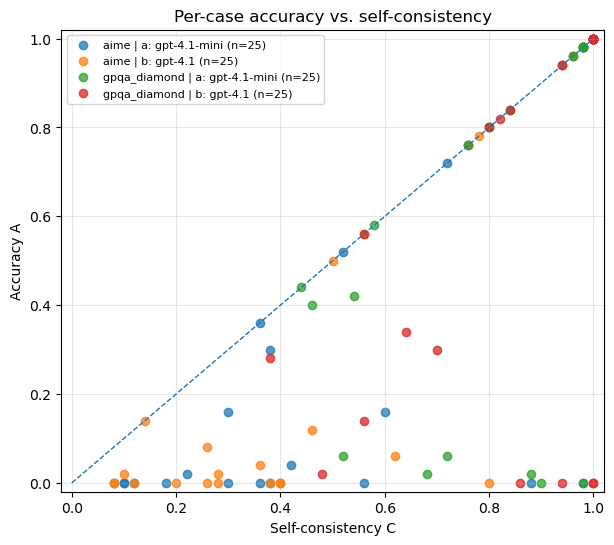

Saved report_figures\01_scatter_C_vs_A.png


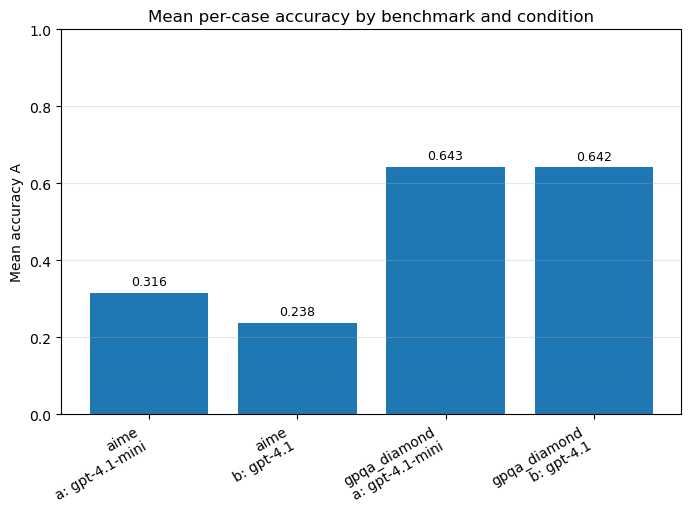

Saved report_figures\02_mean_accuracy_by_segment.png


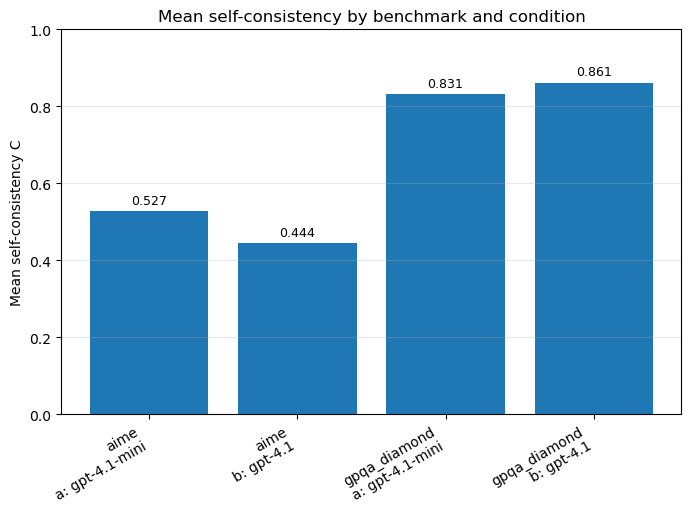

Saved report_figures\03_mean_consistency_by_segment.png


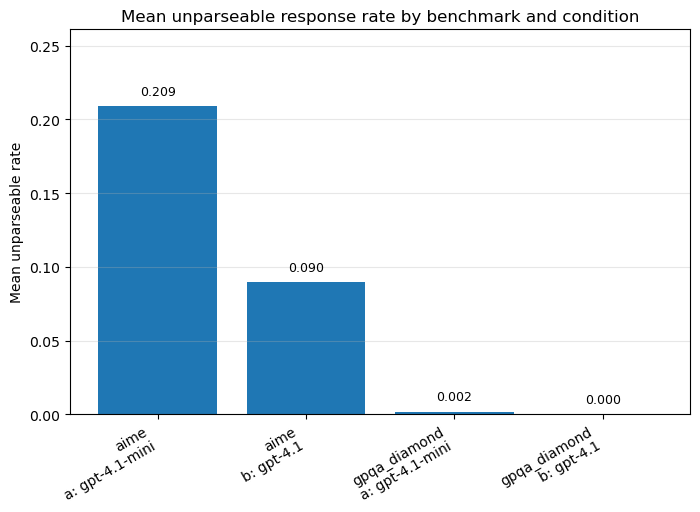

Saved report_figures\04_unparseable_rate_by_segment.png


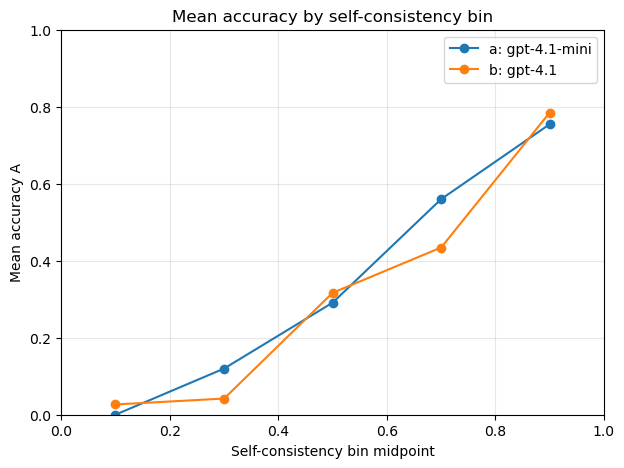

Saved report_figures\05_accuracy_by_consistency_bin.png


,benchmark,mean_delta_A,median_delta_A,n_cases
0,aime,-0.0776,0.0,25
1,gpqa_diamond,-0.0016,0.0,25


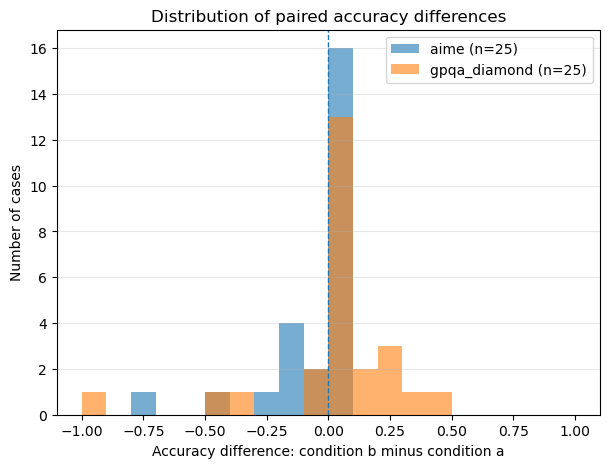

Saved report_figures\06_delta_accuracy_b_minus_a.png


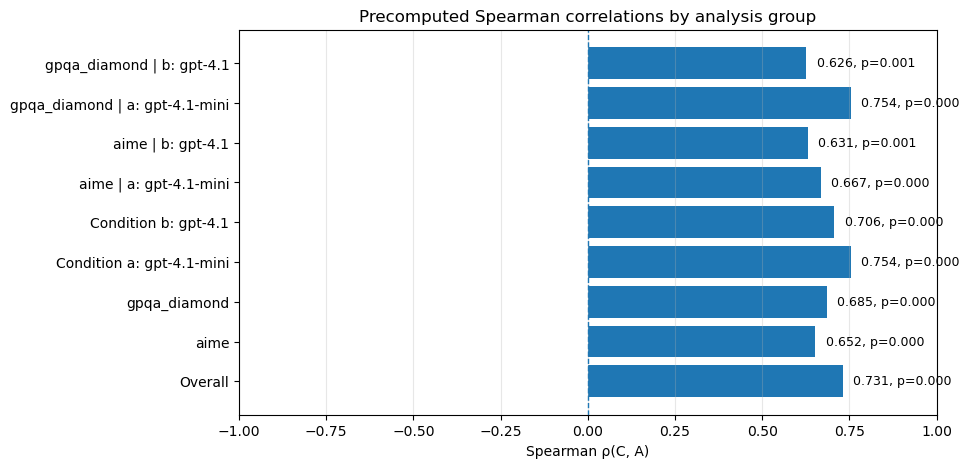

Saved report_figures\07_spearman_correlations.png


,benchmark,condition,n_cases,spearman_rho,p_value
5,aime,a,25,0.6672,0.0003
6,aime,b,25,0.6307,0.0007
7,gpqa_diamond,a,25,0.7537,0.0000
8,gpqa_diamond,b,25,0.6265,0.0008


,benchmark,condition,model,n_cases,spearman_rho,p_value
5,aime,a,gpt-4.1-mini,25,0.6672,0.0003
6,aime,b,gpt-4.1,25,0.6307,0.0007
7,gpqa_diamond,a,gpt-4.1-mini,25,0.7537,0.0000
8,gpqa_diamond,b,gpt-4.1,25,0.6265,0.0008


In [22]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Configuration
# -----------------------------

PENN_KEY = "asudit"  

RESULTS_PATH = Path(f"{PENN_KEY}_results.json")
SPEARMAN_PATH = Path(f"{PENN_KEY}_spearman.csv")
FIG_DIR = Path("report_figures")
FIG_DIR.mkdir(exist_ok=True)


# -----------------------------
# Load final results and precomputed Spearman table
# -----------------------------

with RESULTS_PATH.open("r") as f:
    payload = json.load(f)

meta = payload["meta"]
df = pd.DataFrame(payload["results"])

spearman_df = pd.read_csv(SPEARMAN_PATH)

condition_to_model = {
    "a": meta["condition_a_model"],
    "b": meta["condition_b_model"],
}

df["model_name"] = df["condition"].map(condition_to_model)
df["segment"] = (
    df["benchmark"]
    + " | "
    + df["condition"]
    + ": "
    + df["model_name"]
)


# -----------------------------
# Derived columns
# -----------------------------

df["unparseable_count"] = df["answer_counts"].apply(
    lambda d: int(d.get("_UNPARSEABLE_", 0))
)
df["unparseable_rate"] = df["unparseable_count"] / df["K"]


def majority_is_correct(row):
    if row["benchmark"] == "aime":
        return row["majority_answer"] == int(row["ground_truth"])

    return str(row["majority_answer"]).upper() == str(row["ground_truth"]).upper()


df["majority_correct"] = df.apply(majority_is_correct, axis=1).astype(int)


# -----------------------------
# Summary table
# -----------------------------

segment_summary = (
    df.groupby(["benchmark", "condition", "model_name"])
    .agg(
        n_cases=("case_id", "count"),
        mean_C=("C", "mean"),
        median_C=("C", "median"),
        mean_A=("A", "mean"),
        median_A=("A", "median"),
        mean_R_wilson=("R_wilson", "mean"),
        majority_accuracy=("majority_correct", "mean"),
        mean_unparseable_rate=("unparseable_rate", "mean"),
    )
    .reset_index()
    .round(4)
)

segment_summary.to_csv(FIG_DIR / "segment_summary.csv", index=False)

display(segment_summary)
display(spearman_df)


# -----------------------------
# Plot helper
# -----------------------------

def save_current_figure(filename):
    path = FIG_DIR / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


# -----------------------------
# Chart 1: Scatterplot C vs A
# -----------------------------

plt.figure(figsize=(7, 6))

for label, group in df.groupby("segment"):
    plt.scatter(
        group["C"],
        group["A"],
        alpha=0.75,
        label=f"{label} (n={len(group)})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Self-consistency C")
plt.ylabel("Accuracy A")
plt.title("Per-case accuracy vs. self-consistency")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

save_current_figure("01_scatter_C_vs_A.png")


# -----------------------------
# Chart 2: Mean accuracy by segment
# -----------------------------

plot_df = segment_summary.copy()
plot_df["label"] = (
    plot_df["benchmark"]
    + "\n"
    + plot_df["condition"]
    + ": "
    + plot_df["model_name"]
)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["mean_A"])
plt.ylabel("Mean accuracy A")
plt.title("Mean per-case accuracy by benchmark and condition")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["mean_A"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

save_current_figure("02_mean_accuracy_by_segment.png")


# -----------------------------
# Chart 3: Mean consistency by segment
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["mean_C"])
plt.ylabel("Mean self-consistency C")
plt.title("Mean self-consistency by benchmark and condition")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["mean_C"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center", fontsize=9)

save_current_figure("03_mean_consistency_by_segment.png")


# -----------------------------
# Chart 4: Mean unparseable rate by segment
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["mean_unparseable_rate"])
plt.ylabel("Mean unparseable rate")
plt.title("Mean unparseable response rate by benchmark and condition")

upper = max(0.05, plot_df["mean_unparseable_rate"].max() * 1.25)
plt.ylim(0, upper)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["mean_unparseable_rate"]):
    plt.text(i, value + upper * 0.03, f"{value:.3f}", ha="center", fontsize=9)

save_current_figure("04_unparseable_rate_by_segment.png")


# -----------------------------
# Chart 5: Accuracy by consistency bin
# -----------------------------

df["C_bin"] = pd.cut(
    df["C"],
    bins=np.linspace(0, 1, 6),
    include_lowest=True,
)

bin_summary = (
    df.groupby(["condition", "C_bin"], observed=True)
    .agg(
        mean_A=("A", "mean"),
        n_cases=("case_id", "count"),
    )
    .reset_index()
)

bin_summary["C_midpoint"] = bin_summary["C_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(7, 5))

for condition, group in bin_summary.groupby("condition"):
    model_name = condition_to_model.get(condition, condition)

    plt.plot(
        group["C_midpoint"],
        group["mean_A"],
        marker="o",
        label=f"{condition}: {model_name}",
    )

plt.xlabel("Self-consistency bin midpoint")
plt.ylabel("Mean accuracy A")
plt.title("Mean accuracy by self-consistency bin")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

save_current_figure("05_accuracy_by_consistency_bin.png")


# -----------------------------
# Chart 6: Paired difference, condition b minus condition a
# -----------------------------

wide = df.pivot_table(
    index=["benchmark", "case_id"],
    columns="condition",
    values=["A", "C", "R_wilson"],
    aggfunc="first",
)

wide.columns = [f"{metric}_{condition}" for metric, condition in wide.columns]
wide = wide.reset_index()

if {"A_a", "A_b"}.issubset(wide.columns):
    wide["delta_A_b_minus_a"] = wide["A_b"] - wide["A_a"]

    delta_summary = (
        wide.groupby("benchmark")
        .agg(
            mean_delta_A=("delta_A_b_minus_a", "mean"),
            median_delta_A=("delta_A_b_minus_a", "median"),
            n_cases=("case_id", "count"),
        )
        .reset_index()
        .round(4)
    )

    delta_summary.to_csv(FIG_DIR / "delta_accuracy_summary.csv", index=False)
    display(delta_summary)

    plt.figure(figsize=(7, 5))

    for benchmark, group in wide.groupby("benchmark"):
        plt.hist(
            group["delta_A_b_minus_a"],
            bins=np.linspace(-1, 1, 21),
            alpha=0.6,
            label=f"{benchmark} (n={len(group)})",
        )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Accuracy difference: condition b minus condition a")
    plt.ylabel("Number of cases")
    plt.title("Distribution of paired accuracy differences")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_current_figure("06_delta_accuracy_b_minus_a.png")
else:
    print("Skipping paired delta chart because both conditions were not found.")


# -----------------------------
# Chart 7: Precomputed Spearman correlations
# -----------------------------

rho_plot = spearman_df.dropna(subset=["spearman_rho"]).copy()

def spearman_label(row):
    benchmark = row["benchmark"]
    condition = row["condition"]

    if benchmark == "all" and condition == "all":
        return "Overall"

    if benchmark != "all" and condition == "all":
        return f"{benchmark}"

    if benchmark == "all" and condition != "all":
        model_name = condition_to_model.get(condition, condition)
        return f"Condition {condition}: {model_name}"

    model_name = condition_to_model.get(condition, condition)
    return f"{benchmark} | {condition}: {model_name}"


rho_plot["label"] = rho_plot.apply(spearman_label, axis=1)

rho_plot["sort_key"] = rho_plot.apply(
    lambda row: (
        0 if row["benchmark"] == "all" and row["condition"] == "all"
        else 1 if row["benchmark"] != "all" and row["condition"] == "all"
        else 2 if row["benchmark"] == "all" and row["condition"] != "all"
        else 3,
        row["benchmark"],
        row["condition"],
    ),
    axis=1,
)

rho_plot = rho_plot.sort_values("sort_key").reset_index(drop=True)

plt.figure(figsize=(9, max(5, 0.45 * len(rho_plot))))

y_positions = np.arange(len(rho_plot))

plt.barh(y_positions, rho_plot["spearman_rho"])
plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_positions, rho_plot["label"])
plt.xlabel("Spearman ρ(C, A)")
plt.title("Precomputed Spearman correlations by analysis group")
plt.xlim(-1, 1)
plt.grid(axis="x", alpha=0.3)

for i, row in rho_plot.iterrows():
    rho = row["spearman_rho"]
    p_value = row.get("p_value", np.nan)

    if pd.isna(p_value):
        text = f"{rho:.3f}"
    else:
        text = f"{rho:.3f}, p={p_value:.3f}"

    x = rho + 0.03 if rho >= 0 else rho - 0.03
    ha = "left" if rho >= 0 else "right"

    plt.text(x, i, text, va="center", ha=ha, fontsize=9)

save_current_figure("07_spearman_correlations.png")

per_cell = spearman_df[
    (spearman_df["benchmark"] != "all") &
    (spearman_df["condition"] != "all")
].copy()

display(per_cell)

per_cell_report = per_cell.copy()

per_cell_report["model"] = per_cell_report["condition"].map({
    "a": "gpt-4.1-mini",
    "b": "gpt-4.1",
})

per_cell_report = per_cell_report[
    ["benchmark", "condition", "model", "n_cases", "spearman_rho", "p_value"]
].sort_values(["benchmark", "condition"])

display(per_cell_report)